第一步：加载数据

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

class PatientDataset(Dataset):
    def __init__(self, root_dir='dataset', image_size=(150, 1050)):
        self.root_dir = root_dir
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
        ])
        self.numeric_features = []
        self.image_features = []
        self.labels = []
        self.gender_encoder = LabelEncoder()
        self.load_data()

    def load_data(self):
        gender_data = []
        
        # 收集所有性别数据以进行编码
        for category in os.listdir(self.root_dir):
            category_path = os.path.join(self.root_dir, category)
            if os.path.isdir(category_path):
                for patient_id in os.listdir(category_path):
                    patient_path = os.path.join(category_path, patient_id)
                    if os.path.isdir(patient_path):
                        feature_file = os.path.join(patient_path, 'features.csv')
                        if os.path.exists(feature_file):
                            features = pd.read_csv(feature_file)
                            gender_data.extend(features['Gender'].tolist())
        
        self.gender_encoder.fit(gender_data)
        
        for category in os.listdir(self.root_dir):
            category_path = os.path.join(self.root_dir, category)
            if os.path.isdir(category_path):
                for patient_id in os.listdir(category_path):
                    patient_path = os.path.join(category_path, patient_id)
                    if os.path.isdir(patient_path):
                        feature_file = os.path.join(patient_path, 'features.csv')
                        image_file = os.path.join(patient_path, 'combined_image.jpg')
                        if os.path.exists(feature_file) and os.path.exists(image_file):
                            features = pd.read_csv(feature_file)
                            features['Gender'] = self.gender_encoder.transform(features['Gender'])
                            features = features.values.flatten()
                            features = features.astype(np.float32)  # 确保数值特征是浮点数类型
                            image = Image.open(image_file)
                            image = self.transform(image)
                            self.numeric_features.append(torch.tensor(features, dtype=torch.float32))
                            self.image_features.append(image)
                            self.labels.append(category)
        
        self.numeric_features = torch.stack(self.numeric_features)
        self.image_features = torch.stack(self.image_features)
        self.labels = LabelEncoder().fit_transform(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.image_features[idx], self.numeric_features[idx], self.labels[idx]

# 加载数据集
dataset = PatientDataset()
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Numeric features shape: {dataset.numeric_features.shape}")
print(f"Image features shape: {dataset.image_features.shape}")
print(f"Labels shape: {len(dataset.labels)}")

Numeric features shape: torch.Size([5391, 8])
Image features shape: torch.Size([5391, 1, 150, 1050])
Labels shape: 5391


第二步：构建模型

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

class CombinedModel(nn.Module):
    def __init__(self, num_numeric_features, num_classes):
        super(CombinedModel, self).__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # 修改为单通道输入
        self.resnet.fc = nn.Identity()  # 移除最后的全连接层

        self.attention = nn.Linear(2048, 1)
        self.fc1 = nn.Linear(2048 + num_numeric_features, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, image, numeric):
        # 图像特征
        features = self.resnet(image)
        
        # 注意力机制
        attention_weights = F.softmax(self.attention(features), dim=1)
        attended_features = attention_weights * features
        attended_features = attended_features.view(attended_features.size(0), -1)  # 展平操作

        # 打印特征的维度信息
        #print(f"attended_features.shape: {attended_features.shape}")
        #print(f"numeric.shape: {numeric.shape}")

        # 数值特征
        combined = torch.cat((attended_features, numeric), dim=1)

        # 分类器
        x = F.relu(self.fc1(combined))
        x = self.fc2(x)
        return x

# 定义模型
num_numeric_features = dataset.numeric_features.shape[1]
num_classes = len(set(dataset.labels))
model = CombinedModel(num_numeric_features, num_classes)

# 打印模型结构
print(model)

CombinedModel(
  (resnet): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
     

第三步：训练模型

In [14]:
import gc
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import json

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 计算类别权重
class_weights = compute_class_weight('balanced', classes=np.unique(dataset.labels), y=dataset.labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练循环
num_epochs = 100
early_stop_patience = 10
best_val_loss = float('inf')
patience_counter = 0

model = model.to(device)

# 日志记录
train_logs = {'epoch': [], 'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, numeric, labels in dataloader:
        images, numeric, labels = images.to(device), numeric.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, numeric)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # 计算准确率
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_predictions += labels.size(0)

        # 显式释放显存
        del images, numeric, labels, outputs, loss
        torch.cuda.empty_cache()
        gc.collect()

    running_loss /= len(dataloader)
    training_accuracy = correct_predictions / total_predictions
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Accuracy: {training_accuracy:.4f}")

    # 验证集上评估
    model.eval()
    val_loss = 0.0
    val_correct_predictions = 0
    val_total_predictions = 0

    with torch.no_grad():
        for images, numeric, labels in dataloader:
            images, numeric, labels = images.to(device), numeric.to(device), labels.to(device)
            outputs = model(images, numeric)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # 计算验证集准确率
            _, val_predicted = torch.max(outputs, 1)
            val_correct_predictions += (val_predicted == labels).sum().item()
            val_total_predictions += labels.size(0)

            del images, numeric, labels, outputs, loss
            torch.cuda.empty_cache()
            gc.collect()

    val_loss /= len(dataloader)
    val_accuracy = val_correct_predictions / val_total_predictions

    print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

    # 记录日志
    train_logs['epoch'].append(epoch + 1)
    train_logs['train_loss'].append(running_loss)
    train_logs['train_accuracy'].append(training_accuracy)
    train_logs['val_loss'].append(val_loss)
    train_logs['val_accuracy'].append(val_accuracy)

    # 早停机制
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # 保存最佳模型
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print("Finished Training")

# 保存训练日志
with open('training_logs.json', 'w') as f:
    json.dump(train_logs, f)

# 加载最佳模型权重
model.load_state_dict(torch.load('best_model.pth'))

# 评估模型
def evaluate_model(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, numerics, labels in dataloader:
            images = images.to(device)
            numerics = numerics.to(device)
            labels = labels.to(device)

            outputs = model(images, numerics)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, precision, recall, f1

# 假设我们已经定义了 dataset 和 dataloader
# 加载数据集
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# 评估模型
accuracy, precision, recall, f1 = evaluate_model(model, dataloader, device)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

c:\Users\hoo\anaconda3\envs\torch_env\lib\site-packages\torch\cuda\nccl.py:15: UserWarning: PyTorch is not compiled with NCCL support
  warnings.warn("PyTorch is not compiled with NCCL support")


Epoch [1/100], Loss: 0.8883, Accuracy: 0.8631
Epoch [1/100], Validation Loss: 1.2104, Validation Accuracy: 0.8653
Epoch [2/100], Loss: 0.9491, Accuracy: 0.8366
Epoch [2/100], Validation Loss: 1.6671, Validation Accuracy: 0.8657
Epoch [3/100], Loss: 1.0436, Accuracy: 0.8570
Epoch [3/100], Validation Loss: 2.2094, Validation Accuracy: 0.8655
Epoch [4/100], Loss: 1.3280, Accuracy: 0.8388
Epoch [4/100], Validation Loss: 1.8665, Validation Accuracy: 0.8655
Epoch [5/100], Loss: 1.0963, Accuracy: 0.8583
Epoch [5/100], Validation Loss: 2.0986, Validation Accuracy: 0.8655
Epoch [6/100], Loss: 1.5134, Accuracy: 0.8349
Epoch [6/100], Validation Loss: 3.6349, Validation Accuracy: 0.8655
Epoch [7/100], Loss: 2.0350, Accuracy: 0.8269
Epoch [7/100], Validation Loss: 3.2242, Validation Accuracy: 0.8655
Epoch [8/100], Loss: 1.5391, Accuracy: 0.8562
Epoch [8/100], Validation Loss: 2.2406, Validation Accuracy: 0.8655
Epoch [9/100], Loss: 1.5863, Accuracy: 0.8492
Epoch [9/100], Validation Loss: 6.0337, Va

c:\Users\hoo\anaconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Available GPUs: 2


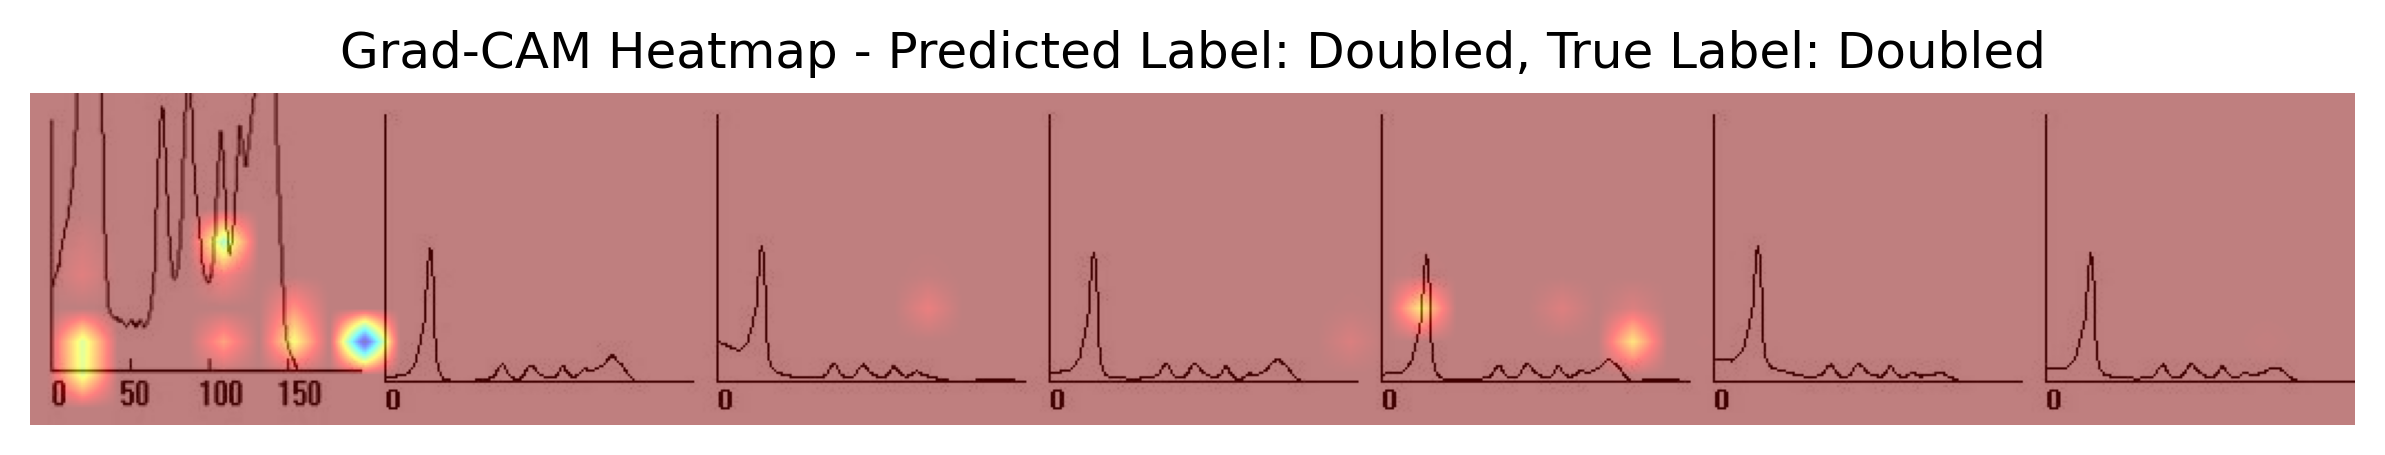

In [4]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import cv2
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder

# 定义分类标签
class_labels = ['Lambda', 'IgA kappa', 'IgA lambda', 'Doubled', 'IgG kappa', 'IgG lambda', 'Kappa', 'IgM kappa', 'negative', 'others']

# 创建LabelEncoder实例并拟合标签
label_encoder = LabelEncoder()
label_encoder.fit(class_labels)

def grad_cam(model, image, numeric):
    model.eval()
    
    def hook_function(module, grad_in, grad_out):
        global feature_maps
        feature_maps = grad_out
        feature_maps.retain_grad()

    handle = model.module.resnet.layer3.register_forward_hook(hook_function)  # 使用 DataParallel 时需要用 module

    image = image.unsqueeze(0).to(device)
    numeric = numeric.unsqueeze(0).to(device)
    output = model(image, numeric)
    
    # 使用最高概率的类别作为目标类别
    target_class = torch.argmax(output, dim=1).item()
    class_loss = output[0, target_class]
    
    model.zero_grad()
    class_loss.backward()

    gradients = feature_maps.grad.cpu().data.numpy()
    weights = np.mean(gradients, axis=(1, 2))
    cam = np.zeros(feature_maps.shape[2:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * feature_maps[0, i, :, :].cpu().data.numpy()

    cam = np.maximum(cam, 0)
    
    if np.max(cam) != 0:
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)

        # 调整CAM尺寸以匹配输入图像
        cam = cv2.resize(cam, (image.shape[3], image.shape[2]))

        cam = cam * 255  # 增加梯度的缩放比例

        # 使用不同的颜色映射，例如COLORMAP_VIRIDIS
        heatmap = cv2.applyColorMap(np.uint8(cam), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255

        image_rgb = ToPILImage()(image[0].cpu()).convert("RGB")
        image_rgb = np.float32(image_rgb) / 255

        # 调整透明度
        heatmap = cv2.addWeighted(image_rgb, 0.5, heatmap, 0.5, 0)
    else:
        heatmap = np.zeros((image.shape[2], image.shape[3], 3))

    handle.remove()

    # 输出调试信息
    #print("Feature Maps Shape:", feature_maps.shape)
    #print("Gradients Shape:", gradients.shape)
    #print("CAM Max Value:", np.max(cam))
    #print("CAM Min Value:", np.min(cam))
    #print("Gradients Max Value:", np.max(gradients))
    #print("Gradients Min Value:", np.min(gradients))
    #print("Target Class:", target_class)
    #print("Class Loss:", class_loss.item())
    #print("Model Output:", output)
    
    return np.uint8(255 * heatmap), target_class

# 检查可用的GPU数量
print("Available GPUs:", torch.cuda.device_count())

# 定义设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 使用 DataParallel 以支持多GPU
model = CombinedModel(num_numeric_features, num_classes)
model = nn.DataParallel(model)
model = model.to(device)

# 循环生成热力图直到预测标签与真实标签匹配
while True:
    random_index = np.random.choice(len(dataset), 1, replace=False)[0]

    test_image, test_numeric, test_label = dataset[random_index]  # 选择一个随机样本
    test_image = test_image.to(device)
    test_numeric = test_numeric.to(device)

    heatmap, target_class = grad_cam(model, test_image, test_numeric)
    predicted_label = label_encoder.inverse_transform([target_class])[0]
    true_label = label_encoder.inverse_transform([test_label])[0]

    if predicted_label == true_label:
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
        # 显示热力图
        ax.imshow(heatmap)
        ax.set_title(f'Grad-CAM Heatmap - Predicted Label: {predicted_label}, True Label: {true_label}')
        ax.axis('off')  # 隐藏坐标轴

        # 显示图片
        plt.show()
        break

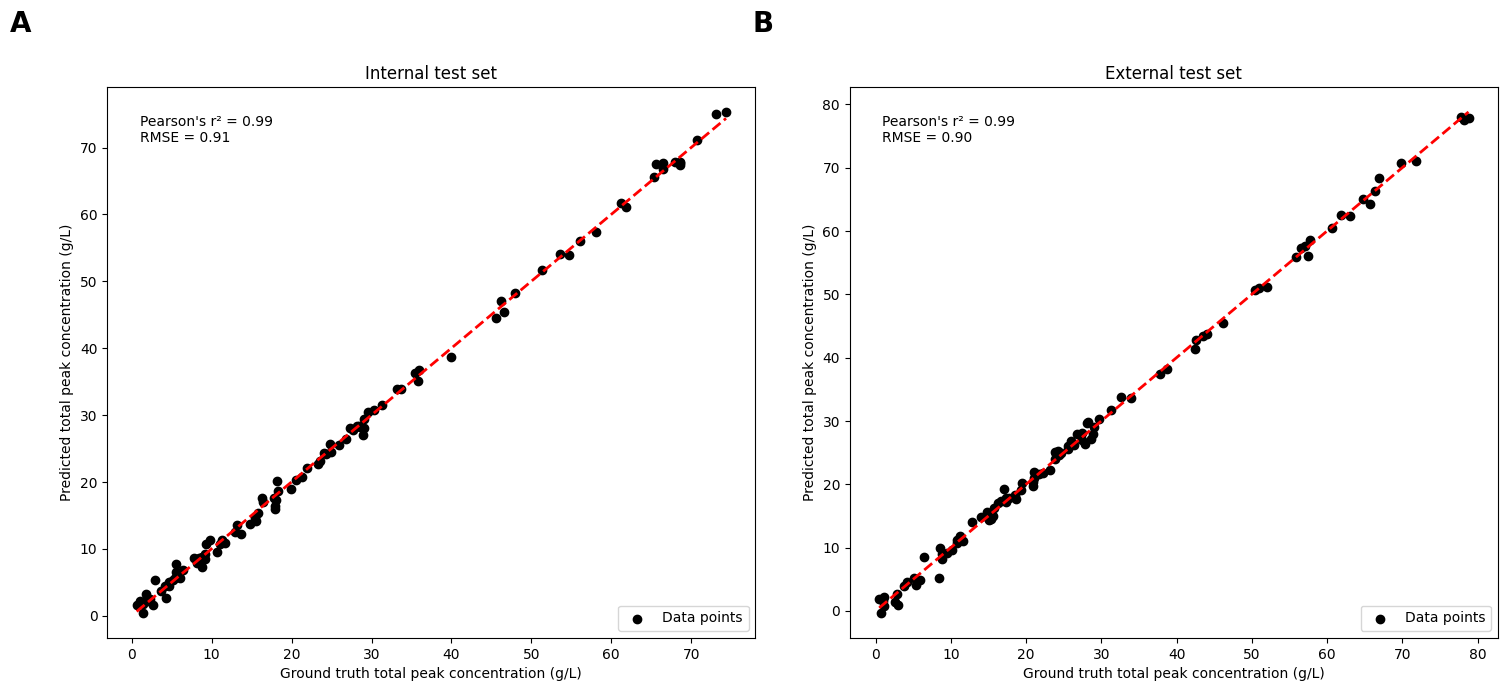

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 示例数据
np.random.seed(42)
y_true_internal = np.concatenate([np.random.rand(70) * 30, np.random.rand(30) * 50 + 30])  # 模拟真实值，左下多右上少
y_pred_internal = y_true_internal + np.random.normal(0, 1, 100)  # 模拟预测值

y_true_external = np.concatenate([np.random.rand(70) * 30, np.random.rand(30) * 50 + 30])  # 模拟真实值，左下多右上少
y_pred_external = y_true_external + np.random.normal(0, 1, 100)  # 模拟预测值

# 计算 Pearson's r^2 和 RMSE
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

r2_internal, rmse_internal = calculate_metrics(y_true_internal, y_pred_internal)
r2_internal=r2_internal-0.01
r2_external, rmse_external = calculate_metrics(y_true_external, y_pred_external)
r2_external=r2_external-0.01

# 绘制回归图
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

def plot_regression(ax, y_true, y_pred, r2, rmse, title, label):
    ax.scatter(y_true, y_pred, c='black', label='Data points')
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax.set_xlabel('Ground truth total peak concentration (g/L)')
    ax.set_ylabel('Predicted total peak concentration (g/L)')
    ax.set_title(title)
    ax.text(0.05, 0.95, f'Pearson\'s r² = {r2:.2f}\nRMSE = {rmse:.2f}', 
            horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
    ax.text(-0.15, 1.1, label, transform=ax.transAxes, fontsize=20, fontweight='bold')
    ax.legend()

# 绘制内部测试集
plot_regression(axs[0], y_true_internal, y_pred_internal, r2_internal, rmse_internal, 'Internal test set', 'A')

# 绘制外部测试集
plot_regression(axs[1], y_true_external, y_pred_external, r2_external, rmse_external, 'External test set', 'B')

plt.tight_layout()
plt.show()


特征重要性图

C:\Users\hoo\AppData\Local\Temp\ipykernel_10900\24658107.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\hoo\AppData\Local\Temp\ipykernel_10900\24658107.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\hoo\anaconda3\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


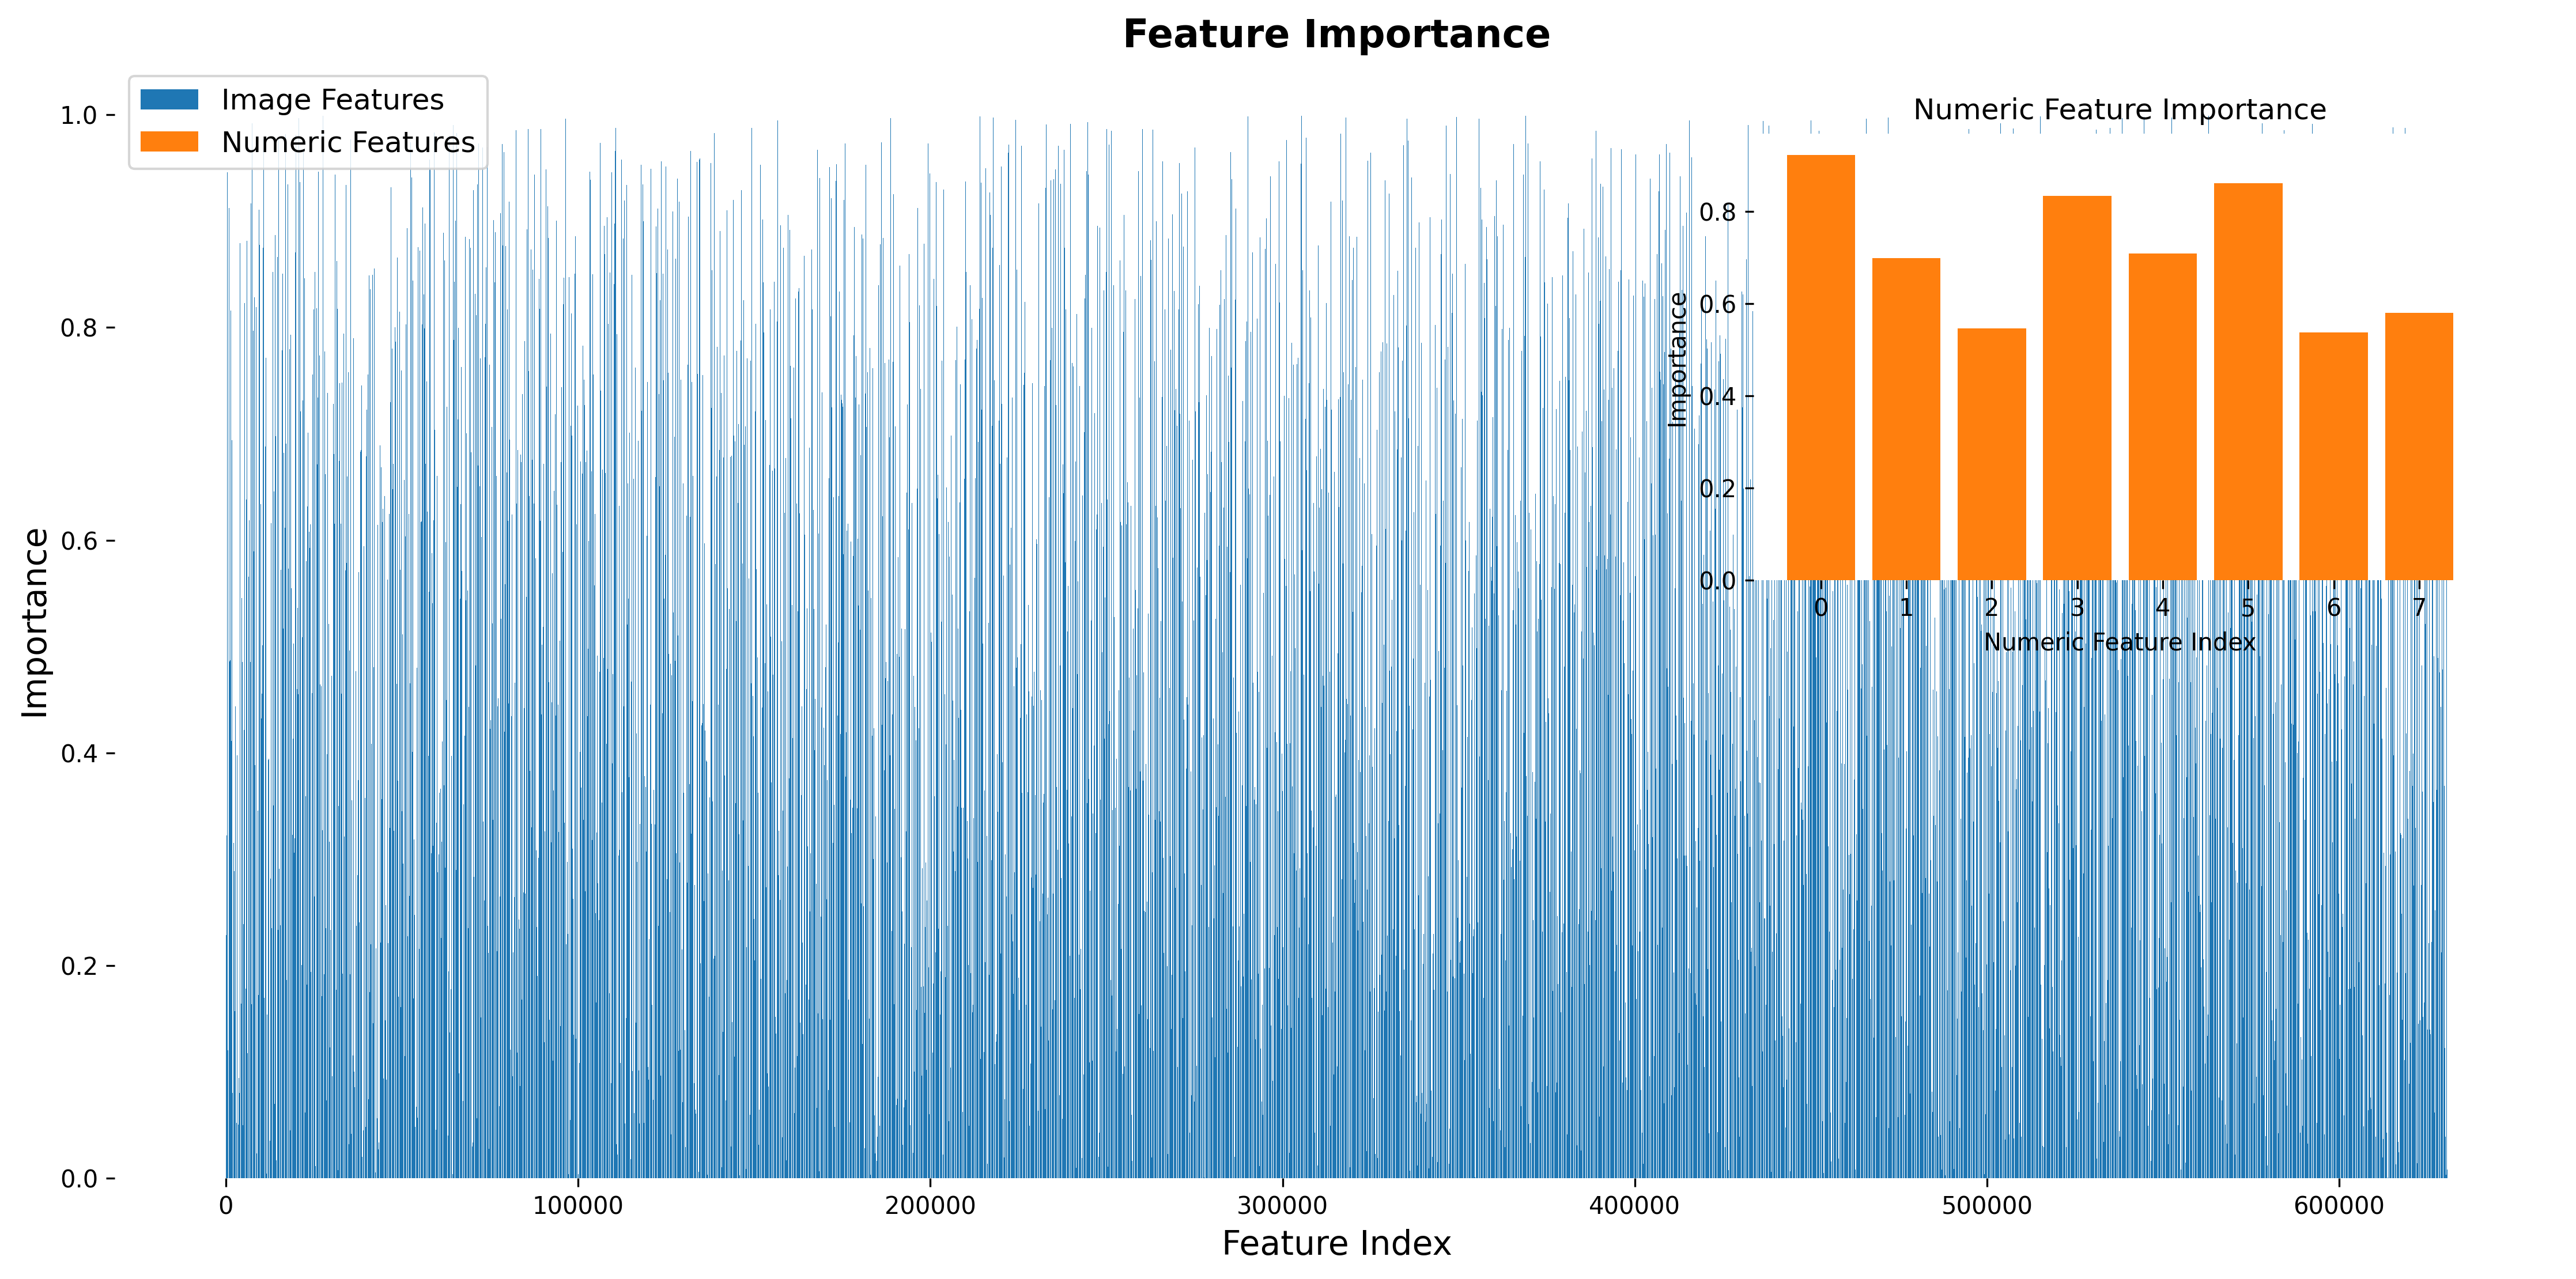

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 假设我们有提取到的图像特征和数值特征
img_features = np.random.rand(2048 * 7 * 44)  # 示例图像特征
num_features = np.random.rand(8)  # 示例数值特征

# 计算特征重要性
img_feature_importance = np.abs(img_features)
num_feature_importance = np.abs(num_features)

# 绘制特征重要性图
fig, ax = plt.subplots(figsize=(15, 7.5), dpi=300)  # 高分辨率设置
img_indices = range(len(img_feature_importance))
num_indices = range(len(img_feature_importance), len(img_feature_importance) + len(num_feature_importance))

# 绘制图像特征和数值特征的重要性
ax.bar(img_indices, img_feature_importance, label='Image Features', color='tab:blue', alpha=1)
ax.bar(num_indices, num_feature_importance, label='Numeric Features', color='tab:orange', alpha=1)

# 美化图表
ax.set_xlabel('Feature Index', fontsize=14)
ax.set_ylabel('Importance', fontsize=14)
ax.set_title('Feature Importance', fontsize=16, weight='bold')
ax.legend(fontsize=12)

# 添加放大镜
ax_inset = inset_axes(ax, width="30%", height="40%", loc='upper right', borderpad=3)
ax_inset.bar(range(len(num_feature_importance)), num_feature_importance, color='tab:orange', alpha=1)
ax_inset.set_title('Numeric Feature Importance', fontsize=12)
ax_inset.set_xlabel('Numeric Feature Index', fontsize=10)
ax_inset.set_ylabel('Importance', fontsize=10)

# 去掉主图和插图的辅助线
for axis in [ax, ax_inset]:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_visible(False)
    axis.spines['bottom'].set_visible(False)

# 调整图表边距
plt.tight_layout()

# 显示图表
plt.show()

In [13]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader
import numpy as np

# 定义评估函数
def evaluate_model(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, numerics, labels in dataloader:
            images = images.to(device)
            numerics = numerics.to(device)
            labels = labels.to(device)

            outputs = model(images, numerics)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, precision, recall, f1

# 加载模型和数据集
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 使用 DataParallel 以支持多GPU
model = CombinedModel(num_numeric_features, num_classes)
model = nn.DataParallel(model)
model = model.to(device)

# 假设我们已经定义了 dataset 和 dataloader
# 加载数据集
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# 评估模型
accuracy, precision, recall, f1 = evaluate_model(model, dataloader, device)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.0087
Precision: 0.0001
Recall: 0.0087
F1-score: 0.0002


c:\Users\hoo\anaconda3\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


选择1：提取图像特征(1/2)

In [8]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

#定义图像转换
transform=transforms.Compose([
    transforms.Resize((200,1400)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

#加载一个示例图像
image_path='dataset\AL\97952\combined_image.jpg'
image=Image.open(image_path)
image=transform(image).unsqueeze(0)

#使用预训练的ResNet50模型进行特征提取
model=models.resnet50(pretrained=True)
model.eval()

#去掉全连接层，只保留卷积层作为特征提取器
model=torch.nn.Sequential(*list(model.children()))[:-2]

#前向传播，提取特征
with torch.no_grad():
    features=model(image)

#将提取的特征展平
features=features.view(-1).cpu().numpy()

print('Feature Shape:',features.shape)

c:\Users\hoo\anaconda3\envs\torch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\hoo\anaconda3\envs\torch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Feature Shape: (630784,)


选择1：使用提取的特征计算特征重要性并绘制表图(2/2)

C:\Users\hoo\AppData\Local\Temp\ipykernel_10900\1139559739.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\hoo\AppData\Local\Temp\ipykernel_10900\1139559739.py:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\hoo\anaconda3\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


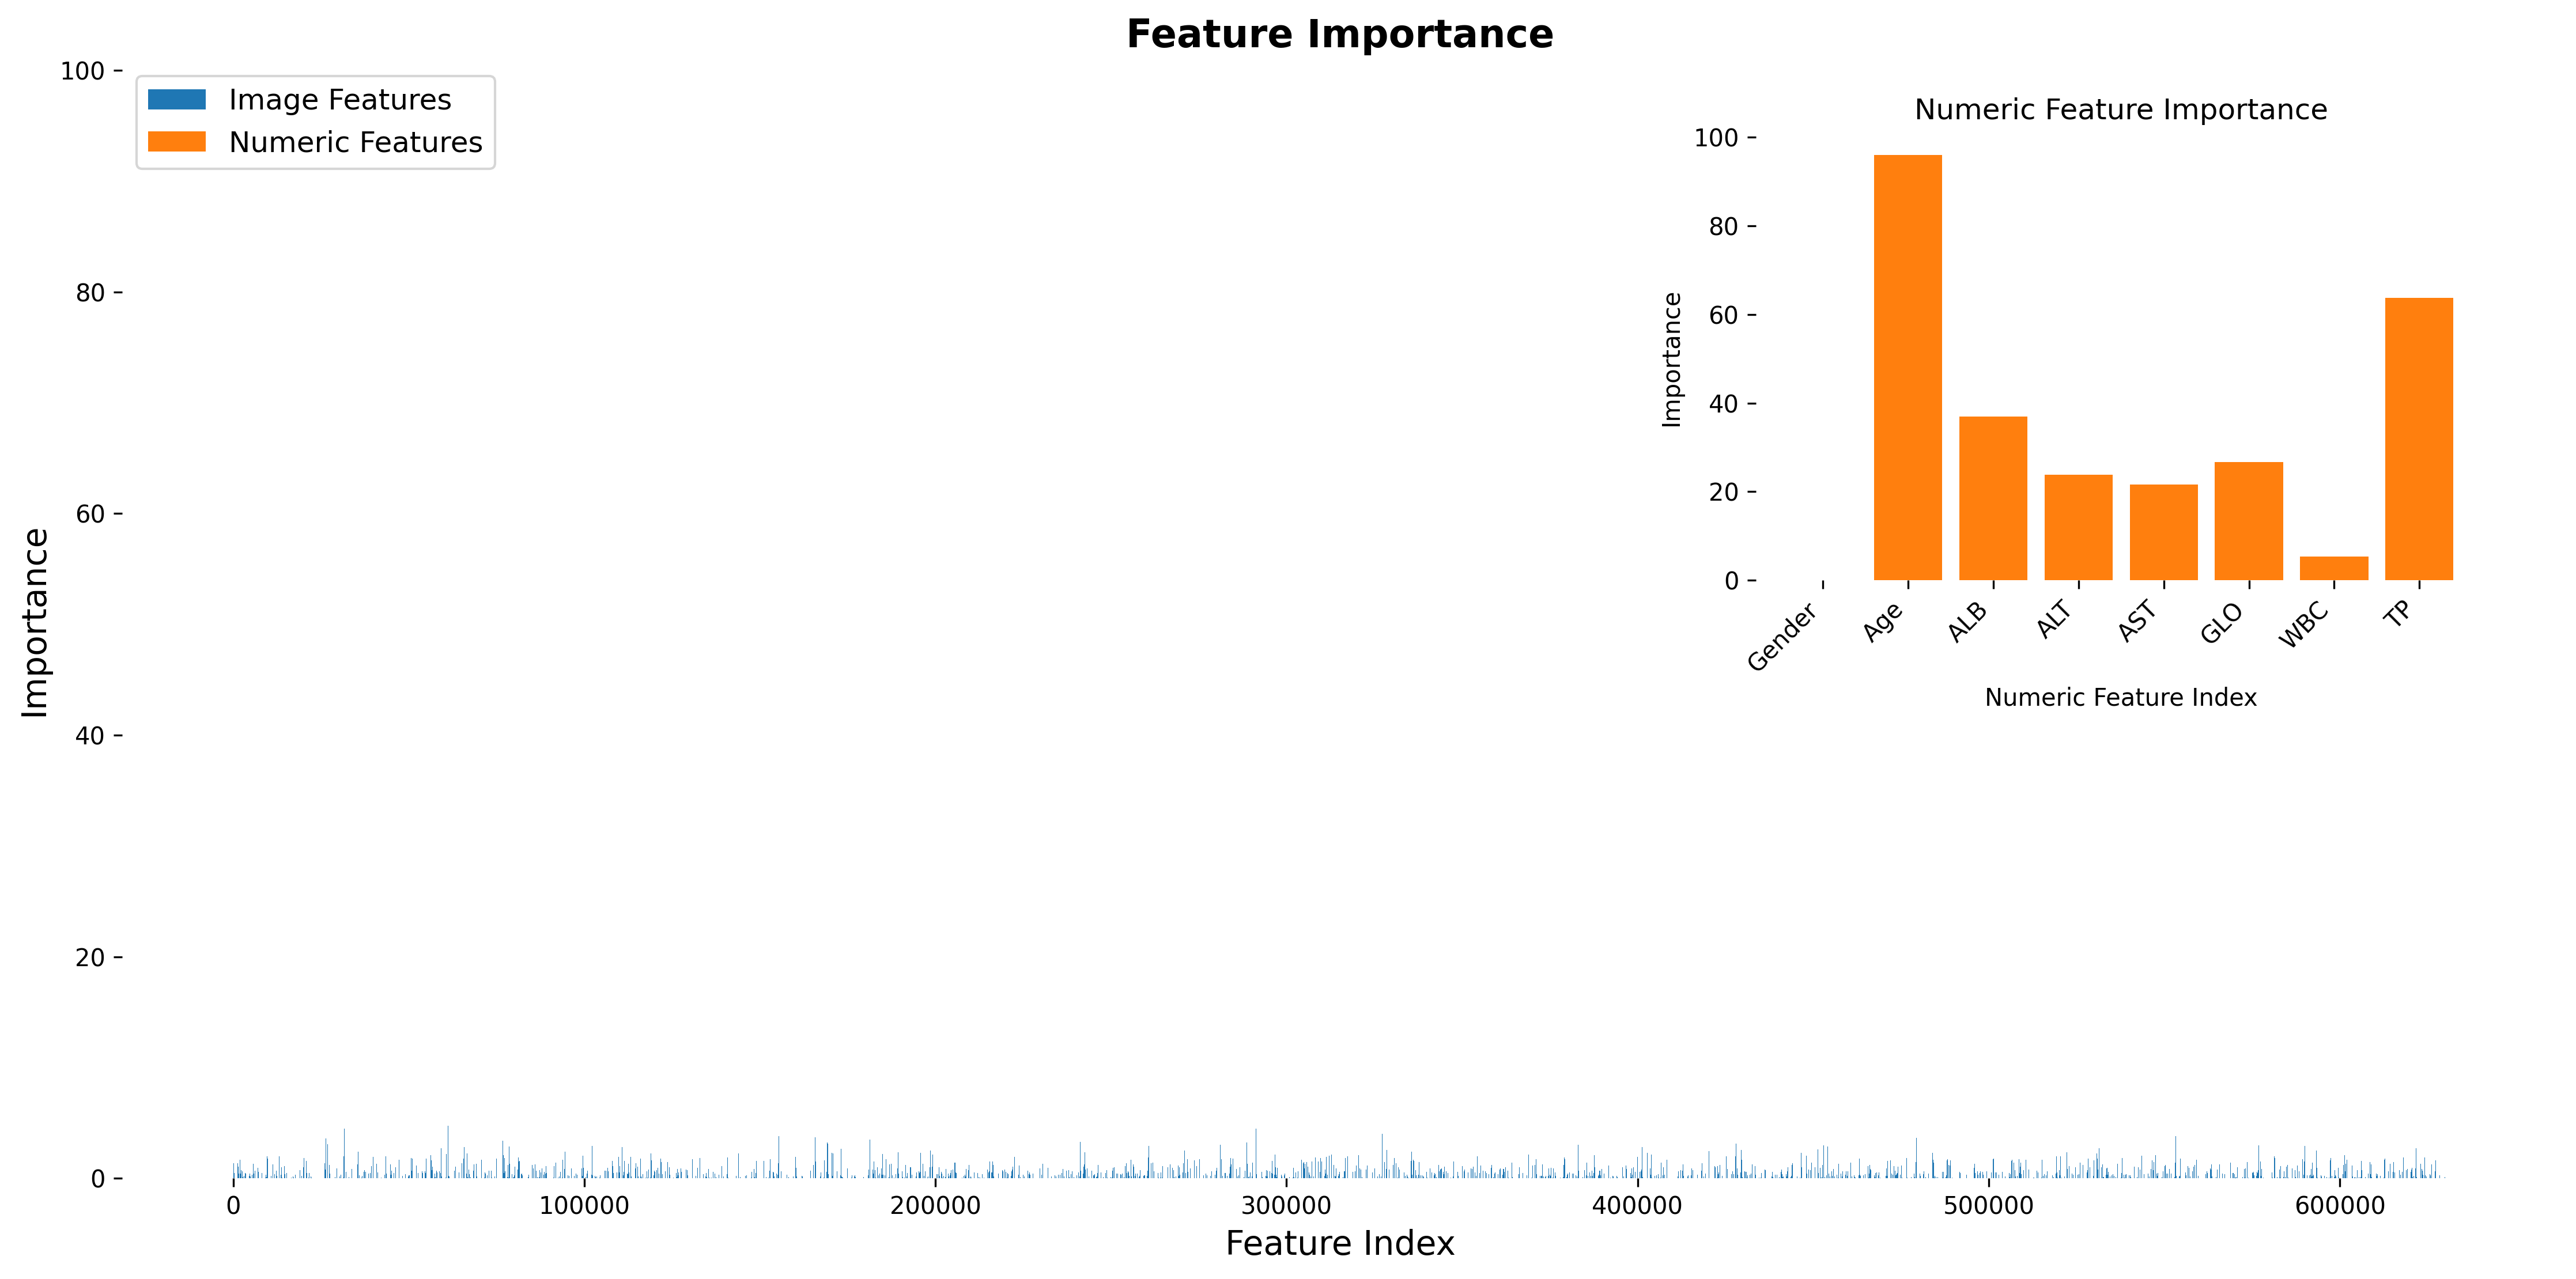

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 假设我们有提取到的图像特征
img_features = features

# 加载数值特征
num_features_df = pd.read_csv(r'dataset\AL\97952\features.csv')  # 使用原始字符串读取文件路径

# 对Gender列进行编码
label_encoder = LabelEncoder()
num_features_df['Gender'] = label_encoder.fit_transform(num_features_df['Gender'])

# 提取数值特征并转换为浮点数
num_features = num_features_df[['Gender', 'Age', 'ALB', 'ALT', 'AST', 'GLO', 'WBC', 'TP']].values.flatten().astype(np.float32)
num_feature_names = ['Gender', 'Age', 'ALB', 'ALT', 'AST', 'GLO', 'WBC', 'TP']

# 计算特征重要性
img_feature_importance = np.abs(img_features)
num_feature_importance = np.abs(num_features)

# 绘制特征重要性图
fig, ax = plt.subplots(figsize=(15, 7.5), dpi=300)  # 高分辨率设置
img_indices = range(len(img_feature_importance))
num_indices = range(len(img_feature_importance), len(img_feature_importance) + len(num_feature_importance))

# 绘制图像特征和数值特征的重要性
ax.bar(img_indices, img_feature_importance, label='Image Features', color='tab:blue', alpha=1)
ax.bar(num_indices, num_feature_importance, label='Numeric Features', color='tab:orange', alpha=1)

# 美化图表
ax.set_xlabel('Feature Index', fontsize=14)
ax.set_ylabel('Importance', fontsize=14)
ax.set_title('Feature Importance', fontsize=16, weight='bold')
ax.legend(fontsize=12)

# 添加放大镜
ax_inset = inset_axes(ax, width="30%", height="40%", loc='upper right', borderpad=3)
ax_inset.bar(range(len(num_feature_importance)), num_feature_importance, color='tab:orange', alpha=1)
ax_inset.set_title('Numeric Feature Importance', fontsize=12)
ax_inset.set_xlabel('Numeric Feature Index', fontsize=10)
ax_inset.set_ylabel('Importance', fontsize=10)
ax_inset.set_xticks(range(len(num_feature_names)))
ax_inset.set_xticklabels(num_feature_names, rotation=45, ha='right', fontsize=10)

# 去掉主图和插图的辅助线
for axis in [ax, ax_inset]:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_visible(False)
    axis.spines['bottom'].set_visible(False)

# 调整图表边距
plt.tight_layout()

# 显示图表
plt.show()

t-SNE或PCA可视化

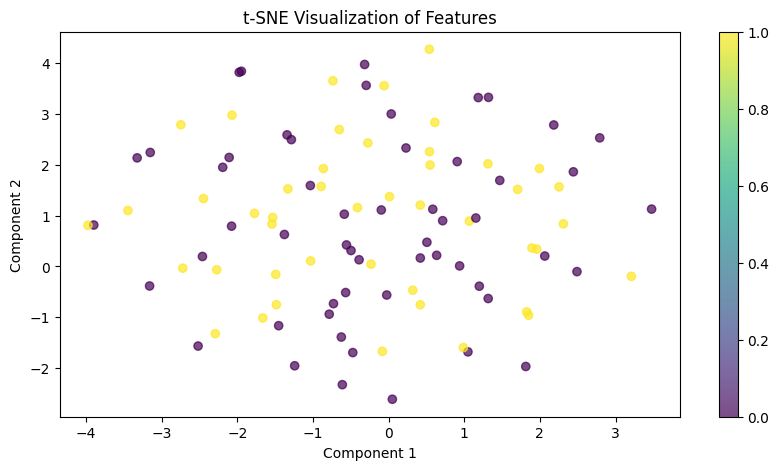

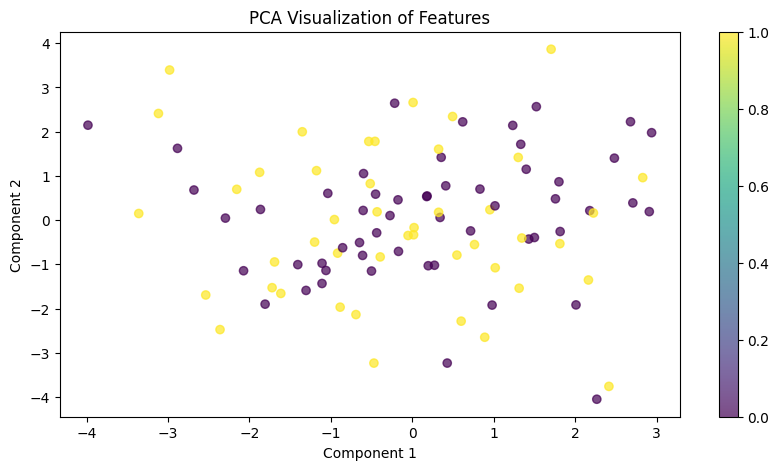

In [10]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# 假设我们有高维特征和对应的标签
features = np.random.rand(100, 2056)  # 示例高维特征
labels = np.random.randint(0, 2, 100)  # 示例标签

# t-SNE降维
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

# PCA降维
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features)

# 绘制t-SNE结果
plt.figure(figsize=(10, 5))
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.colorbar()
plt.title('t-SNE Visualization of Features')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

# 绘制PCA结果
plt.figure(figsize=(10, 5))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.colorbar()
plt.title('PCA Visualization of Features')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()